In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"D:\Exercisee\housing.csv"

df = pd.read_csv(file_path)

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
print("Rows and columns:", df.shape)

df.info()

Rows and columns: (20640, 10)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [4]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26480\24631494.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)


In [6]:
from sklearn.model_selection import train_test_split

#seperate input features and target 
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

#Split into training and testing data
X_train, X_test, y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training data shape: (16512, 9)
Testing data shape: (4128, 9)
Training target shape: (16512,)
Testing target shape: (4128,)


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Find numeric columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Text columns 
categorical_features = ['ocean_proximity']

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
Categorical features: ['ocean_proximity']


In [8]:
import sklearn

In [9]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print("Preprocessor created successfully.")

NameError: name 'Pipeline' is not defined

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=-1))
])
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Make predictions on the test houses
predictions = model.predict(X_test)

#calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 31636.19363129845
Mean Squared Error (MSE): 2398820115.3845725
Root Mean Squared Error (RMSE): 48977.751228334
R-squared (R2): 0.8169411111174801


In [ ]:
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

results.head(10)

,Actual Price,Predicted Price
0,47700.0,51744.00
1,45800.0,70992.00
2,500001.0,461540.37
3,218600.0,255273.00
4,278000.0,268203.00
5,158700.0,162987.00
6,198200.0,226729.02
7,157500.0,168559.00
8,340000.0,288998.05
9,446600.0,484186.71


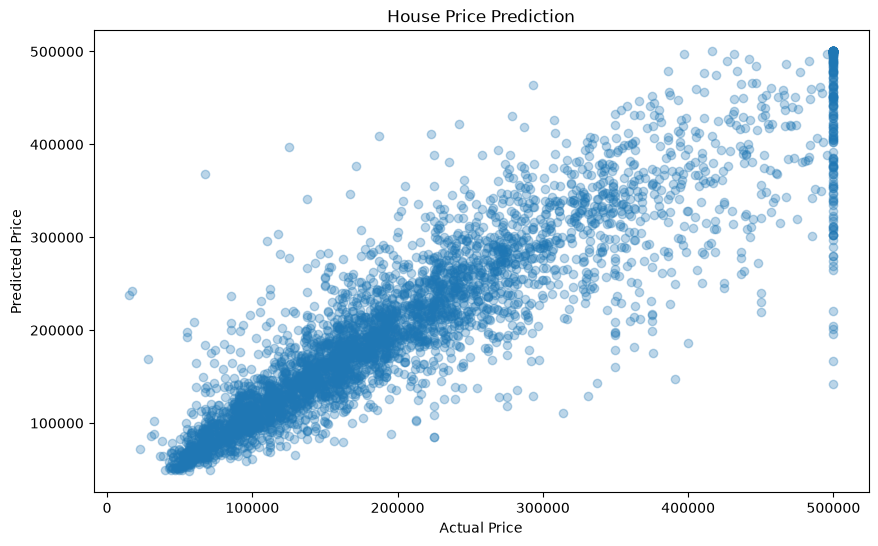

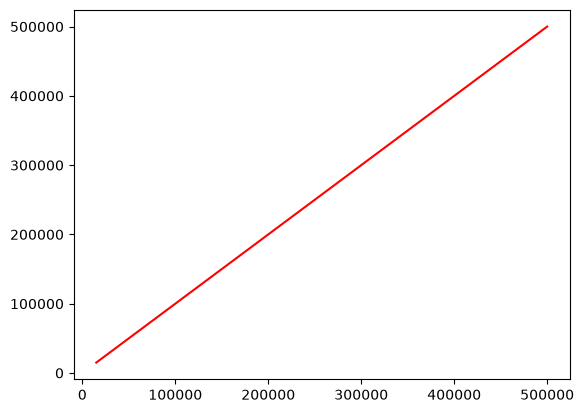

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(results["Actual Price"], results["Predicted Price"], alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("House Price Prediction")
plt.show()

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.show()

In [ ]:
import joblib

joblib.dump(model, "house_price_model.pkl",compress=3)

print("Compressed Model saved successfully.")

Compressed Model saved successfully.


In [ ]:
new_house = pd.DataFrame({
    "longitude": [-122.23],
    "latitude": [37.88],
    "housing_median_age": [41],
    "total_rooms": [880],
    "total_bedrooms": [176],
    "population": [1296],
    "households": [496],
    "ocean_proximity": ["NEAR BAY"],
    "median_income": [4.0],
    "median_house_value": [45000]

})

predicted_price = model.predict(new_house)
print("Predicted price for the new house:", predicted_price[0])

Predicted price for the new house: 216431.01


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = ["ocean_proximity"]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessor recreated successfully.")

Preprocessor recreated successfully.


In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

comparison = []

for name, regressor in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor)
    ])

    pipeline.fit(X_train, y_train)

    predictions_model = pipeline.predict(X_test)

    comparison.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions_model),
        "R2 Score": r2_score(y_test, predictions_model)
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

comparison_df

,Model,MAE,R2 Score
1,Random Forest,31636.193631,0.816941
2,Gradient Boosting,38249.308474,0.761726
0,Linear Regression,50670.738241,0.625424


In [16]:
from sklearn.model_selection import RandomizedSearchCV

tunning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
         random_state=42, n_jobs=-1))

])

parameters = {
    "regressor__n_estimators": [100,150,200],
    "regressor__max_depth": [None, 10,20,30],
    "regressor__min_samples_split": [2,5,10],
    "regressor__min_samples_leaf": [1,2,4]
}

search = RandomizedSearchCV(
    estimator=tunning_pipeline,
    param_distributions=parameters,
    n_iter=10,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
    scoring='neg_mean_absolute_error'

)
search.fit(X_train,y_train)

print("Best parameters found: ", search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters found:  {'regressor__n_estimators': 200, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 2, 'regressor__max_depth': None}


In [17]:
tuned_predictions = search.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_r2 = r2_score(y_test, tuned_predictions)

print(f"Tuned MAE:${tuned_mae:,.2f}")
print(f"Tuned R2 Score: {tuned_r2:.4f}")

Tuned MAE:$31,477.80
Tuned R2 Score: 0.8181


In [19]:
import joblib
joblib.dump(
    search.best_estimator_,
    "house_price_model.pkl",
    compress=3
)

print("Tuned model saved successfully.")

Tuned model saved successfully.
